In [1]:
unzip("northstar_dataset.zip", exdir = "data")

list.files("data")

[1] "northstar_dataset"

In [2]:
install.packages(c("readr","dplyr","sqldf"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [3]:
library(readr)
library(dplyr)
library(sqldf)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [4]:
path <- "data/northstar_dataset/"

orders <- read_csv(paste0(path,"orders.csv"))
deliveries <- read_csv(paste0(path,"deliveries.csv"))

print(dim(orders))
print(dim(deliveries))

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 1250   11
[1] 950  13


In [5]:
service_counts <- sqldf("
SELECT
    service_type,
    COUNT(*) as total_orders
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")

print(service_counts)

  service_type total_orders
1    Passenger          341
2       Parcel          308
3       Retail          297
4     Business          165
5      Medical          139


In [6]:
delivery_status_analysis <- sqldf("
SELECT
    delivery_status,
    COUNT(*) as total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC
")

print(delivery_status_analysis)

  delivery_status total_deliveries
1          OnTime              616
2         Delayed              202
3          Failed              132


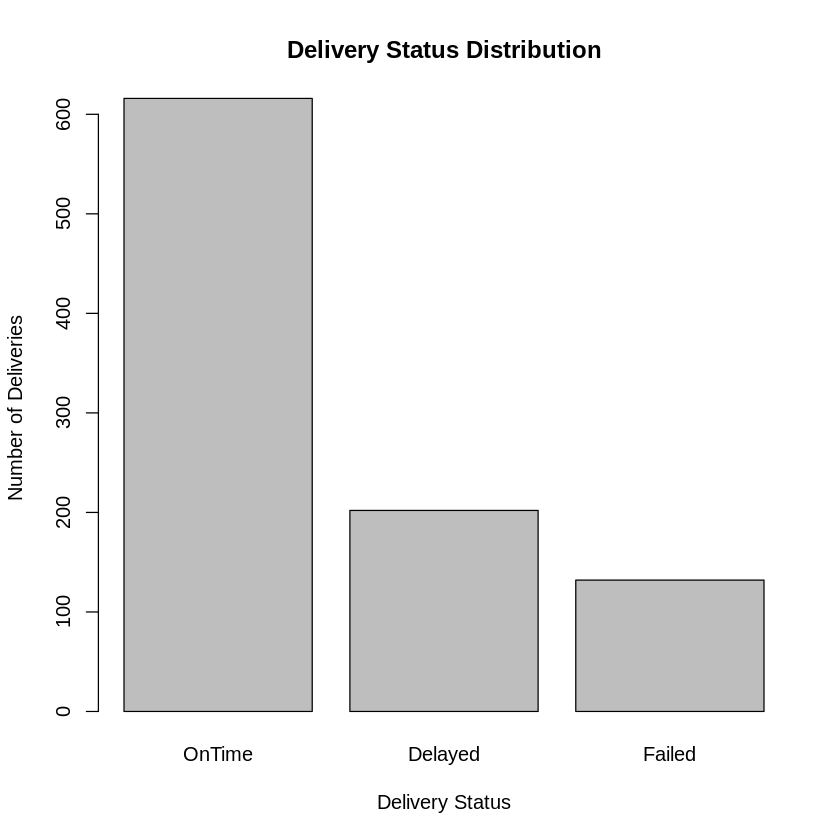

In [7]:
barplot(
  delivery_status_analysis$total_deliveries,

  names.arg = delivery_status_analysis$delivery_status,

  main = "Delivery Status Distribution",

  xlab = "Delivery Status",

  ylab = "Number of Deliveries"
)